# Importing Packages

In [10]:
from qiskit import quantum_info as qi
import numpy as np
from matplotlib import pyplot as plt
import matplotlib.colors as colors
import matplotlib as mpl

import sympy as sp
from utils import get_poly_from_code, poly_dicts_to_sympy, get_stabilizer_code

# Graphing Settings

In [17]:
mpl.rcParams.update({
    'text.usetex': True,
    'font.family': 'serif',
    'font.size': 8,
    'axes.labelsize': 9,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 8,
    'lines.linewidth': 1.2,
    'figure.dpi': 150,
})

# Flow Diagrams

In [13]:
x_sym, y_sym, z_sym = sp.symbols('x y z', real=True)

def get_dynamics_for_code(code_name):
    generator_set, logical_operator = get_stabilizer_code(code_name)

    poly_dicts = get_poly_from_code(
        generator_set=generator_set,
        logical_operator=logical_operator
    )

    psuc_sp_origin, Tx_sp_origin, Ty_sp_origin, Tz_sp_origin = poly_dicts_to_sympy(poly_dicts)

    print(f"\n=== Full dynamical system for {code_name} ===")
    print("psuc:", psuc_sp_origin)
    print("Tx:", Tx_sp_origin)
    print("Ty:", Ty_sp_origin)
    print("Tz:", Tz_sp_origin)

    # Restrict to y = 0
    psuc_sp = psuc_sp_origin.subs({y_sym: 0})
    Tx_sp = Tx_sp_origin.subs({y_sym: 0})
    Ty_sp = Ty_sp_origin.subs({y_sym: 0})
    Tz_sp = Tz_sp_origin.subs({y_sym: 0})

    print(f"\n=== y = 0 reduced system for {code_name} ===")
    print("psuc:", psuc_sp)
    print("Tx:", Tx_sp)
    print("Ty:", Ty_sp)
    print("Tz:", Tz_sp)

    # Helpful sanity check
    if sp.simplify(Ty_sp) != 0:
        print(f"Warning: for {code_name}, Ty is nonzero on y=0.")
        print("So the y=0 plane is not invariant; this plot is only the x-z projection.")

    Tx = sp.lambdify((x_sym, z_sym), Tx_sp, modules="numpy")
    Tz = sp.lambdify((x_sym, z_sym), Tz_sp, modules="numpy")

    def vector_field(x, z):
        x_out = Tx(x, z)
        z_out = Tz(x, z)
        return x_out - x, z_out - z

    return vector_field


def plot_dynamics(ax, code_name, grid_size=50):
    vector_field = get_dynamics_for_code(code_name)

    xs = np.linspace(0, 1, grid_size)
    zs = np.linspace(0, 1, grid_size)
    X, Z = np.meshgrid(xs, zs)

    U, V = vector_field(X, Z)

    ax.streamplot(
        X, Z, U, V,
        broken_streamlines=True,
        color="lightblue",
        zorder=0
    )

    # Bloch sphere boundary in x-z plane
    theta = np.linspace(0, np.pi / 2, 1000)
    ax.plot(
        np.cos(theta),
        np.sin(theta),
        "-.",
        linewidth=2,
        color="C0"
    )

    # Stabilizer octahedron boundary x + z = 1
    line = np.linspace(0, 1, 100)
    ax.plot(
        line,
        1 - line,
        "-.",
        linewidth=2,
        color="C0"
    )

    # Region outside the Bloch disk
    xs_fill = np.linspace(0, 1, 100)
    ax.fill_between(
        xs_fill,
        np.sqrt(1 - xs_fill**2),
        1,
        interpolate=False,
        color="lightgrey"
    )

    # x = z line
    diag = np.linspace(0, 1 / np.sqrt(2), 100)
    ax.plot(
        diag,
        diag,
        "--",
        color="orange"
    )

    ax.set_xlabel("x")
    ax.set_ylabel("z")
    ax.set_title(f"Dynamics of {code_name}")

    ax.axhline(0, color="black", linewidth=0.5)
    ax.axvline(0, color="black", linewidth=0.5)

    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1])
    ax.set_aspect("equal", adjustable="box")
    ax.grid()


=== Full dynamical system for 2_1_1 ===
psuc: z**2 + 1
Tx: 2*z/(z**2 + 1)
Ty: -2*x*y/(z**2 + 1)
Tz: (x**2 - y**2)/(z**2 + 1)

=== y = 0 reduced system for 2_1_1 ===
psuc: z**2 + 1
Tx: 2*z/(z**2 + 1)
Ty: 0
Tz: x**2/(z**2 + 1)

=== Full dynamical system for 3_1_1 ===
psuc: x**2*z + x*y**2 + x*z + 1
Tx: (x*y**2 + x*z - y**2*z + z**2)/(x**2*z + x*y**2 + x*z + 1)
Ty: (x*y*z - x*y - y*z**2 - y*z)/(x**2*z + x*y**2 + x*z + 1)
Tz: (x**2*z + x*z + x + y**2)/(x**2*z + x*y**2 + x*z + 1)

=== y = 0 reduced system for 3_1_1 ===
psuc: x**2*z + x*z + 1
Tx: (x*z + z**2)/(x**2*z + x*z + 1)
Ty: 0
Tz: (x**2*z + x*z + x)/(x**2*z + x*z + 1)


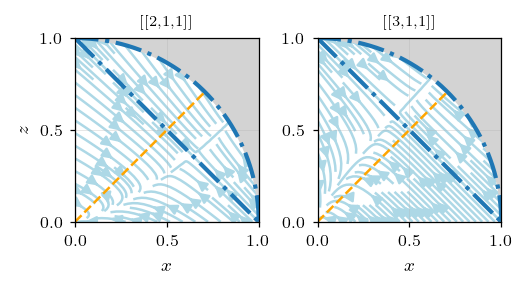

In [18]:
fig, axes = plt.subplots(
    1, 2,
    figsize=(3.4, 1.75),   # single-column APS width
    constrained_layout=True
)

plot_dynamics(axes[0], "2_1_1", grid_size=35)
plot_dynamics(axes[1], "3_1_1", grid_size=35)

# Shorter panel titles
axes[0].set_title(r"[[2,1,1]]")
axes[1].set_title(r"[[3,1,1]]")

# Reduce visual clutter
for ax in axes:
    ax.set_xlabel(r"$x$")
    ax.set_ylabel(r"$z$")
    ax.set_xticks([0, 0.5, 1])
    ax.set_yticks([0, 0.5, 1])
    ax.grid(alpha=0.35, linewidth=0.4)

# Avoid duplicate y-label if you want it even cleaner
axes[1].set_ylabel("")

plt.show()

In [31]:
def plot_dynamics_compact(ax, code_name, grid_size=35):
    vector_field = get_dynamics_for_code(code_name)

    xs = np.linspace(0, 1, grid_size)
    zs = np.linspace(0, 1, grid_size)
    X, Z = np.meshgrid(xs, zs)

    U, V = vector_field(X, Z)

    # Mask the unphysical region outside the Bloch disk
    mask = X**2 + Z**2 > 1
    U = np.where(mask, np.nan, U)
    V = np.where(mask, np.nan, V)

    # Sparse streamlines
    ax.streamplot(
        X, Z, U, V,
        density=0.90,              # main crowding control
        linewidth=0.45,
        arrowsize=0.55,
        color='lightblue',
        broken_streamlines=True,
        integration_direction='forward',
        maxlength=0.8,
        zorder=1
    )

    # Bloch sphere boundary
    theta = np.linspace(0, np.pi / 2, 500)
    ax.plot(
        np.cos(theta), np.sin(theta),
        '-.',
        linewidth=0.8,
        color='C0',
        alpha=0.75,
        zorder=3
    )

    # Stabilizer octahedron boundary x + z = 1
    line = np.linspace(0, 1, 300)
    ax.plot(
        line, 1 - line,
        '-.',
        linewidth=0.8,
        color='C0',
        alpha=0.75,
        zorder=3
    )

    # Gray out unphysical region
    xs_fill = np.linspace(0, 1, 300)
    ax.fill_between(
        xs_fill,
        np.sqrt(1 - xs_fill**2),
        1,
        color='lightgrey',
        alpha=0.6,
        zorder=0
    )

    # x = z guide line
    diag = np.linspace(0, 1 / np.sqrt(2), 200)
    ax.plot(
        diag, diag,
        '--',
        linewidth=0.8,
        color='orange',
        alpha=0.8,
        zorder=3
    )

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_aspect('equal', adjustable='box')

    ax.set_xlabel(r'$x$')
    ax.set_ylabel(r'$z$')

    ax.set_xticks([0, 0.5, 1])
    ax.set_yticks([0, 0.5, 1])

    ax.grid(alpha=0.18, linewidth=0.35)

    ax.axhline(0, color='black', linewidth=0.4)
    ax.axvline(0, color='black', linewidth=0.4)


=== Full dynamical system for 2_1_1 ===
psuc: z**2 + 1
Tx: 2*z/(z**2 + 1)
Ty: -2*x*y/(z**2 + 1)
Tz: (x**2 - y**2)/(z**2 + 1)

=== y = 0 reduced system for 2_1_1 ===
psuc: z**2 + 1
Tx: 2*z/(z**2 + 1)
Ty: 0
Tz: x**2/(z**2 + 1)

=== Full dynamical system for 3_1_1 ===
psuc: x**2*z + x*y**2 + x*z + 1
Tx: (x*y**2 + x*z - y**2*z + z**2)/(x**2*z + x*y**2 + x*z + 1)
Ty: (x*y*z - x*y - y*z**2 - y*z)/(x**2*z + x*y**2 + x*z + 1)
Tz: (x**2*z + x*z + x + y**2)/(x**2*z + x*y**2 + x*z + 1)

=== y = 0 reduced system for 3_1_1 ===
psuc: x**2*z + x*z + 1
Tx: (x*z + z**2)/(x**2*z + x*z + 1)
Ty: 0
Tz: (x**2*z + x*z + x)/(x**2*z + x*z + 1)


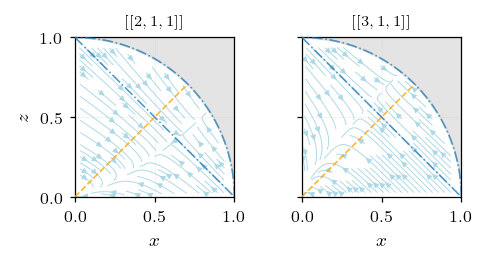

In [32]:
fig, axes = plt.subplots(
    1, 2,
    figsize=(3.35, 1.65),
    sharex=True,
    sharey=True,
    constrained_layout=True
)

plot_dynamics_compact(axes[0], '2_1_1')
plot_dynamics_compact(axes[1], '3_1_1')

axes[0].set_title(r'$[[2,1,1]]$')
axes[1].set_title(r'$[[3,1,1]]$')

# Remove repeated ylabel to save space
axes[1].set_ylabel('')

plt.show()